# Analiza delnic
Na več načinov bom analiziral največjih 500-tih delnic na svetovnem trgu, na njih izvedel hitre Fourierove transformacije in primerjal kako se skupaj primerjajo z indexom S&P 500, ki naj bi posnemal njihovo obnašanje. <br>
Uporabljal bom podatke iz obdobja enega leta (od 1. julija 2025 do 1. julija 2026), ki sem jih pridobil iz strani Yahoo finance. <br>
Za podatke sem si izbral adjusted close price vseh delnic za vsak dan, ko je bila borza odprta, ter market cap, Beta marker in P/E razmerje vseh delnic 1.julija 2026, ko sem podatke pridobil s spleta.

In [69]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.fft import fft, fftfreq

### Izvedimo najprej hitre Fourierove transformacije na indexu S&P 500:

In [70]:
CENE_SP_500 = pd.read_csv('SP_500_cene.csv')
CENE_SP_500_STOLPCI = CENE_SP_500.T.reset_index()
CENE_SP_500_STOLPCI.columns = ['Datum', 'Cena']
CENE_SP_500_STOLPCI = CENE_SP_500_STOLPCI.drop(0).reset_index(drop=True)
CENE_SP_500_STOLPCI['Cena'] = CENE_SP_500_STOLPCI['Cena'].str.replace(',', '')

CENE_SP_500_STOLPCI['Datum'] = pd.to_datetime(CENE_SP_500_STOLPCI['Datum'])
CENE_SP_500_STOLPCI['Cena'] = CENE_SP_500_STOLPCI['Cena'].astype(float)

#izračunamo razliko med podatki
CENE_SP_500_STOLPCI['Donos'] = CENE_SP_500_STOLPCI['Cena'].pct_change()

donosi_cisti = CENE_SP_500_STOLPCI['Donos'].dropna().values
stevilo_trgovalnih_dni = len(donosi_cisti)


fft_vrednosti = fft(donosi_cisti)
frekvence = fftfreq(stevilo_trgovalnih_dni, d=1)

# Jemljemo le pozitivne frekvence, saj je FFT vedmo simetričen
pozitivni_indeksi = frekvence > 0
f_prave = frekvence[pozitivni_indeksi]

#izračunamo moč posamezne frekvence
amplitude = np.abs(fft_vrednosti[pozitivni_indeksi])

#frekvence pretvorimo v periode: perioda = 1 / frekvenca
periode = 1 / f_prave


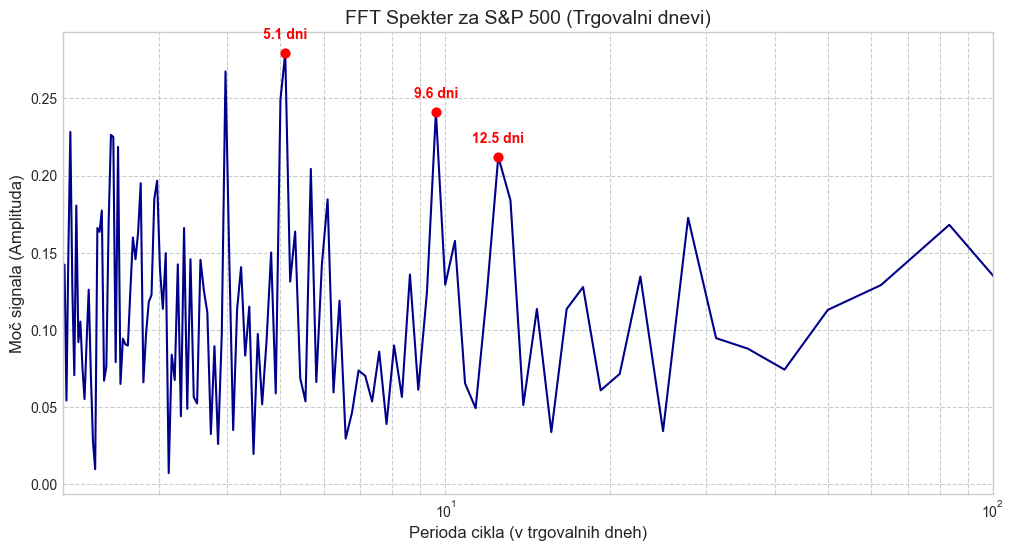

In [71]:
# napisano s pomočjo umetne inteligence
plt.figure(figsize=(12, 6))
plt.plot(periode, amplitude, color='darkblue', linewidth=1.5)
plt.xscale('log')
plt.title('FFT Spekter za S&P 500 (Trgovalni dnevi)', fontsize=14)
plt.xlabel('Perioda cikla (v trgovalnih dneh)', fontsize=12)
plt.ylabel('Moč signala (Amplituda)', fontsize=12)
plt.grid(True, which="both", ls="--")
plt.xlim(2, 100)

indeksi_nad_5d = periode > 5
if np.any(indeksi_nad_5d):
    najvisji_vrhovi = np.argsort(amplitude[indeksi_nad_5d])[-3:]
    for idx in najvisji_vrhovi:
        p_vrh = periode[indeksi_nad_5d][idx]
        a_vrh = amplitude[indeksi_nad_5d][idx]
        plt.scatter(p_vrh, a_vrh, color='red', s=40, zorder=5)
        plt.annotate(f"{p_vrh:.1f} dni", (p_vrh, a_vrh), textcoords="offset points", 
                     xytext=(0,10), ha='center', fontweight='bold', color='red')


plt.show()

### Sledi Fourierova Ekstrapolacija indexa S&P 500:
Fourierova ekstrapolacija poteka v več korakih korakih in sicer:
1. izluščimo že znane podatke o ceni delnic
2. odstranimo trend (dolgoročno trg raste, zato ta trend izračunamo in odstranimo)
3. izvedemo FFT in poiščemo n najmočnejših frekvenc
4. ekstrapoliramo v prihodnost
5. združimo sedanje in prihodnje podatke ter prikažemo v grafu


In [72]:
# najprej izluščimo že dobljene podatke:
predvidevane_cene = CENE_SP_500_STOLPCI.sort_values('Datum').reset_index(drop=True)
y = predvidevane_cene['Cena'].values
stevilo_dni = len(y)
x = np.arange(stevilo_dni)

# poiščemo dolgotranji trend in ga odstranimo
# polyfit poišče najbolj 'ustrezen' polinom željene stopnje, ki se prilega podatkom-tukaj bo to premica
koeficienti_trenda = np.polyfit(x,y,1)
trend = np.polyval(koeficienti_trenda, x)
y_brez_trenda = y - trend

# na dobljenem y-u izvedemo FFT in poiščemo frekvence
y_fft = np.fft.fft(y_brez_trenda)
frekvence = np.fft.fftfreq(stevilo_dni)

# izberemo si koliko frekvenc želimo vzeti - to lahko spreminjamo po želji
stevilo_izbranih_frekvenc = 50
indeksi = np.argsort(np.abs(y_fft))[::-1]

# izberemo koliko dni v prihodnost želimo podaljšati graf
dnevi_v_prihodnost = 200
x_prihodnost = np.arange(stevilo_dni + dnevi_v_prihodnost)

# izvedba ekstrapolacije:
# najprej moramo ustvariti prazen signal za preteklost + prihodnost
rekonstrukcija = np.zeros(len(x_prihodnost))

for index in indeksi[:stevilo_izbranih_frekvenc]:
    amplituda = np.abs(y_fft[index]) / stevilo_dni
    faza = np.angle(y_fft[index])
    f = frekvence[index]
    if f == 0:
        množitelj = 1
    else:
        množitelj = 2
    
    rekonstrukcija += množitelj * amplituda * np.cos(2 * np.pi * f * x_prihodnost + faza)

# sedaj prištejemo nazaj trend - to je trend od prej, le podaljšan v prihodnost
trend_prihodnost = np.polyval(koeficienti_trenda, x_prihodnost)
končna_napoved = rekonstrukcija + trend_prihodnost

# pred izrisom grafa moramo še določiti prihodnje datume, na katere bo borza odprta
# ta del kode za podaljšanje datumov sem pridobil iz interneta
zadnji_datum = predvidevane_cene['Datum'].max()
prihodnji_datumi = pd.bdate_range(start=zadnji_datum + pd.Timedelta(days=1), periods=dnevi_v_prihodnost)
vsi_datumi = pd.concat([predvidevane_cene['Datum'], pd.Series(prihodnji_datumi)]).reset_index(drop=True)

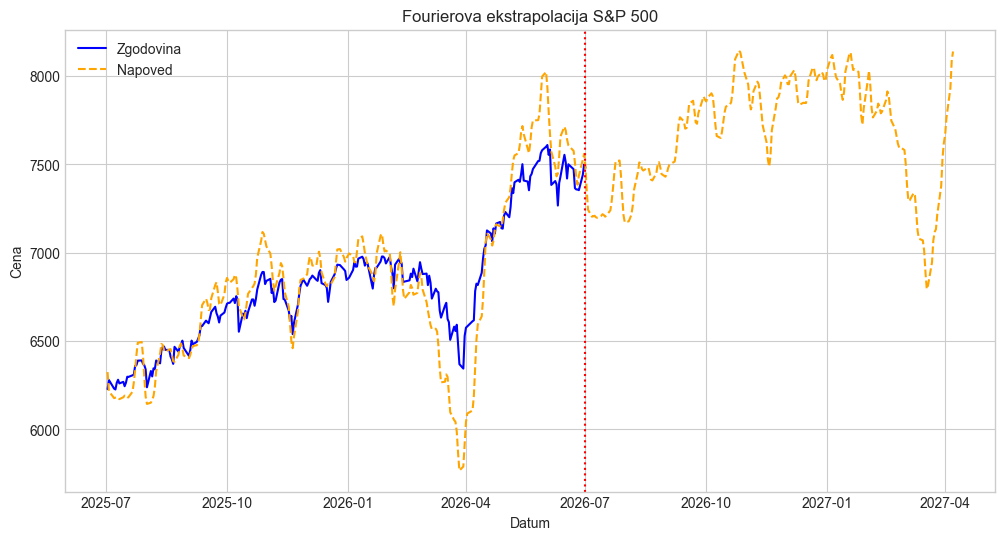

In [73]:
plt.figure(figsize=(12, 6))

plt.plot(vsi_datumi[:stevilo_dni], y, label='Zgodovina', color='blue')
plt.plot(vsi_datumi, končna_napoved, label='Napoved', color='orange', linestyle='--')

# dodamo navpično črto pri datumu, ko so bili podatki zbrani
plt.axvline(x=vsi_datumi[stevilo_dni - 1], color='red', linestyle=':')

plt.title('Fourierova ekstrapolacija S&P 500')
plt.xlabel('Datum')
plt.ylabel('Cena')
plt.legend()

plt.show()

### Sedaj poskusimo iz 500-tih podjetih, o katerih smo zbrali podatke ustvariti "povprečno" delnico
Kasneje bomo primerjali, kako se ta delnica primerja z indexom S&P 500

Pripravimo datoteko s cenami 500-ih delnic za obdelavo:

In [74]:
CENE_500_DELNIC_VRSTICE = pd.read_csv('tickerji_plus_cene.csv',index_col="ticker")

CENE_500_DELNIC = CENE_500_DELNIC_VRSTICE.T
CENE_500_DELNIC.index = pd.to_datetime(CENE_500_DELNIC.index)

# da ne dobimo 1970 bug
if 'Datum' in CENE_500_DELNIC.columns:
    CENE_500_DELNIC = CENE_500_DELNIC.set_index('Datum')

if 'Datum' in CENE_SP_500_STOLPCI.columns:
    CENE_SP_500_STOLPCI = CENE_SP_500_STOLPCI.set_index('Datum')
    
# sortiramo od najstarejšega da najnovejšega
CENE_500_DELNIC = CENE_500_DELNIC.sort_index()
CENE_500_DELNIC = CENE_500_DELNIC.replace({',': ''}, regex=True).astype(float)


Pripravimo datoteko z ostalimi podatki in market cap spremenimo v število:

In [75]:

PODATKI = pd.read_csv('tickerji_s_podatki.csv', names = ['ticker', 'market_cap', 'beta', 'P/E'])
PODATKI = PODATKI.drop(0).reset_index(drop=True)
utezi = PODATKI[['ticker', 'market_cap']]

def pretvori_v_stevilko(vrednost):
    if pd.isna(vrednost):
        return 0
    
    vrednost_str = str(vrednost).upper().strip()
    
    if 'T' in vrednost_str:
        return float(vrednost_str.replace('T', '')) * 1000000000000
    elif 'B' in vrednost_str:
        return float(vrednost_str.replace('B', '')) * 1000000000
    elif 'M' in vrednost_str:
        return float(vrednost_str.replace('M', '')) * 1000000
    else:
        return float(vrednost_str)
    

utezi['market_cap'] = utezi['market_cap'].apply(pretvori_v_stevilko)
PODATKI['market_cap'] = utezi['market_cap']
PODATKI = PODATKI.set_index('ticker')

Sedaj z zbranimi podatki ustvarimo našo "povprečno" delnico:

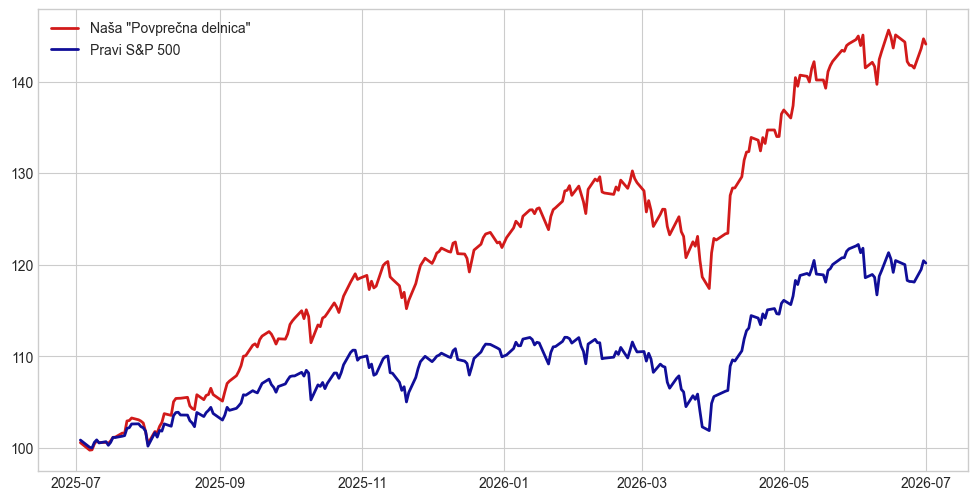

In [76]:

# vzamemo le podjetja, ki obstajajo celo zadnje leto
cene_polne = CENE_500_DELNIC.dropna(axis=1)

# izračunamo uteži
utezi_norm = PODATKI.loc[cene_polne.columns, 'market_cap']
utezi_norm /= utezi_norm.sum()

# izračunamo kumulativne indekse (oba štartata iz baze 100)
sinteticni_indeks = (1 + cene_polne.pct_change().dot(utezi_norm)).cumprod() * 100
pravi_sp500_indeks = (1 + CENE_SP_500_STOLPCI['Cena'].sort_index().pct_change()).cumprod() * 100

# izris grafa
plt.figure(figsize=(12, 6))
plt.plot(sinteticni_indeks, label='Naša "Povprečna delnica"', color="#D21A1A", linewidth=2)
plt.plot(pravi_sp500_indeks, label='Pravi S&P 500', color="#100E98", linewidth=2)
plt.legend()
plt.show()

Opažnja - zakaj je naša "povprečna delnica" toliko boljša od indexa? Survivor bias

## Nadaljujmo z nekoliko lažjo analizo glavnih lastnosti delnic:

Najprej poiščimo tiste delnice, ki 

In [77]:
beta_stolpec = PODATKI['beta']
beta_stolpec

def razlika_do_1(niz):
    return abs(float(niz) - 1)

razlika_beta = beta_stolpec.apply(razlika_do_1)

najlizja_trgu = ''
min_razlika = None

for ticker, razlika in razlika_beta.items():
    if min_razlika is None or razlika < min_razlika:
        min_razlika = razlika
        vsi_najblizji = [ticker]
     
    elif razlika == min_razlika:
        vsi_najblizji.append(ticker)

print(f"Najdene delnice, ki najbolje posnemajo trg: {vsi_najblizji}")
print(f"Trg posnemajo z {min_razlika * 100}% napako (zaokroženo na dve decimalki)")

    

Najdene delnice, ki najbolje posnemajo trg: ['JPM', 'CSCO', 'JPM-PC', 'JPM-PD', 'KYCCF', 'USB', 'USB-PH', 'CNI', 'USB-PP']
Trg posnemajo z 0.0% napako (zaokroženo na dve decimalki)


Iz zgornjega vidimo, da...

Poglejmo si še kolikšen delež 500-tih največjih podjetih (glede na market cap) predstavlja največjih n podjetij, ko n spreminjamo:

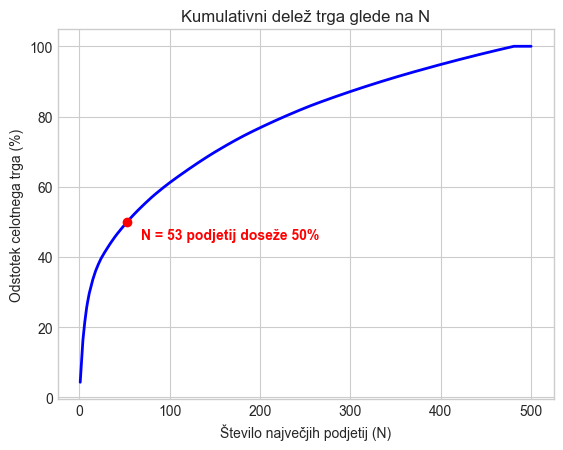

In [78]:

urejen_mcap = PODATKI["market_cap"].sort_values(ascending=False)

kumulativni_procent = (urejen_mcap.cumsum() / urejen_mcap.sum()) * 100

n_osi = np.arange(1, 501)

# poiščemo tisti n, ki je prvi, pri katerem število podjetij predstavlja več kot 50% trga
n_50 = len(kumulativni_procent[kumulativni_procent < 50]) + 1

plt.plot(n_osi, kumulativni_procent, color="blue", linewidth=2)
plt.title("Kumulativni delež trga glede na N")
plt.xlabel("Število največjih podjetij (N)")
plt.ylabel("Odstotek celotnega trga (%)")

plt.scatter(n_50, 50, color="red", zorder=5)
plt.text(n_50 + 15, 45, f"N = {n_50} podjetij doseže 50%", color="red", fontweight="bold")

plt.show()
